# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
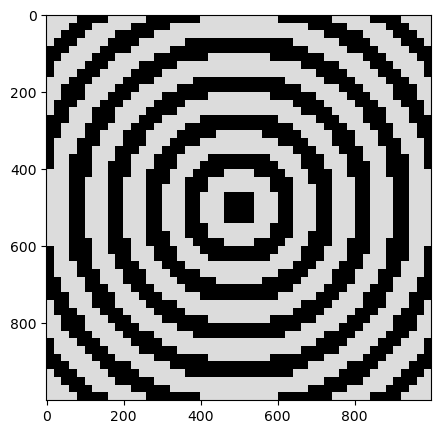


In [ ]:
#EL panadero con el pan

# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
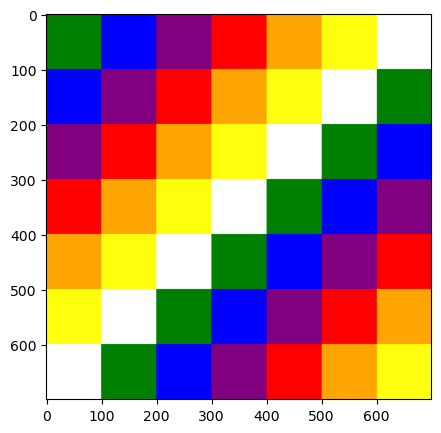

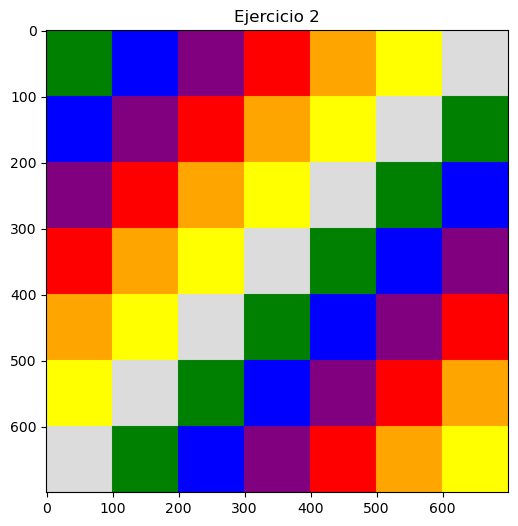

True

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [6, 6]

bloque = 100
n = 7
img2 = np.zeros((n * bloque, n * bloque, 3), dtype=np.uint8)

colores = [
    [0, 128, 0],      
    [0, 0, 255],      
    [128, 0, 128],    
    [255, 0, 0],      
    [255, 165, 0],    
    [255, 255, 0],    
    [220, 220, 220]  
]

for i in range(n):
    for j in range(n):
        idx = (i + j) % n
        f0, f1 = i * bloque, (i + 1) * bloque
        c0, c1 = j * bloque, (j + 1) * bloque
        img2[f0:f1, c0:c1] = colores[idx]

plt.imshow(img2)
plt.title('Ejercicio 2')
plt.axis('on')
plt.show()

cv2.imwrite('ej2.png', cv2.cvtColor(img2, cv2.COLOR_RGB2BGR))

# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

Punto random (x, y): (435, 102)


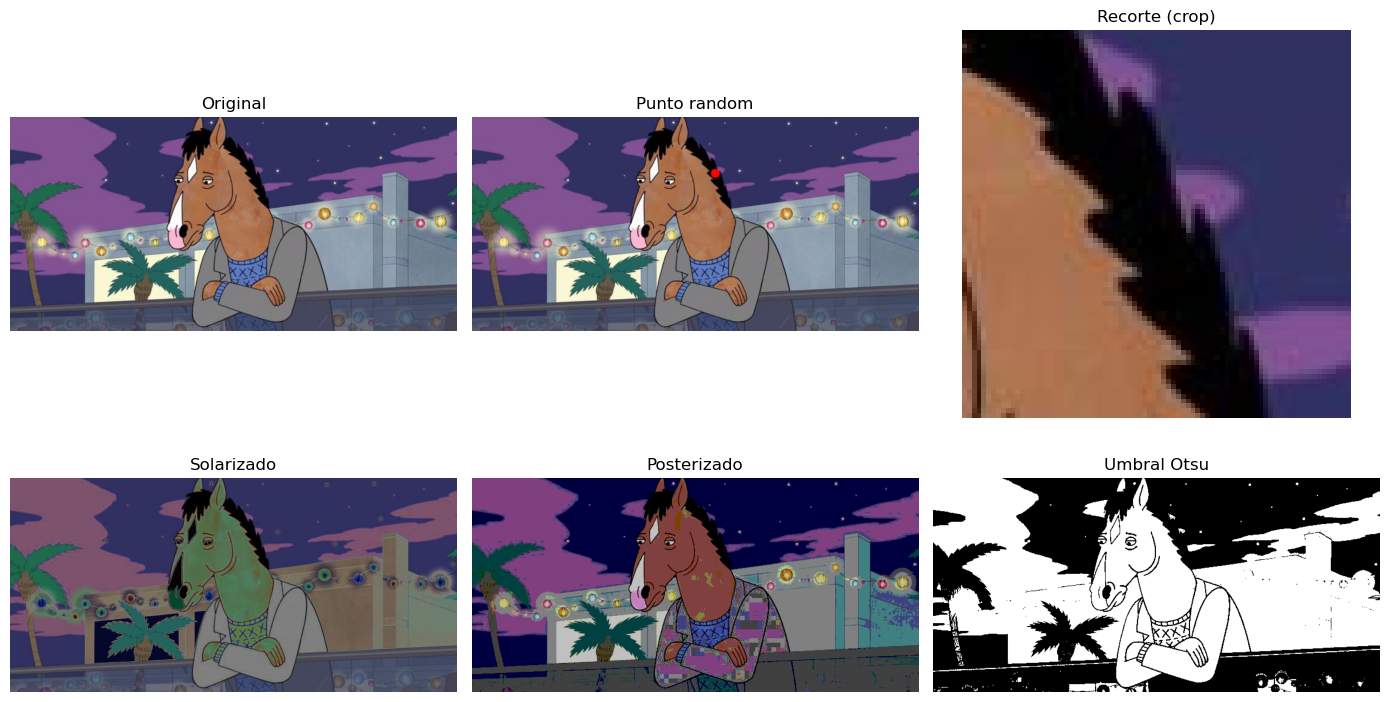

Guardado: punto_random, recorte_crop, solarizado, posterizado, umbral_otsu, artistico_crop


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [14, 8]

img_bgr = cv2.imread('imagen1.jpg')
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Punto random
np.random.seed(42)
ry = np.random.randint(0, h)
rx = np.random.randint(0, w)
print('Punto random (x, y):', (rx, ry))

img_punto = img.copy()
cv2.circle(img_punto, (rx, ry), 8, (255, 0, 0), -1)


size_crop = 80
y1 = max(0, ry - size_crop//2)
y2 = min(h, ry + size_crop//2)
x1 = max(0, rx - size_crop//2)
x2 = min(w, rx + size_crop//2)
crop = img[y1:y2, x1:x2]

# Solar
solar = img.copy()
mask = solar > 128
solar[mask] = 255 - solar[mask]

# Posterizado
poster = (img // 64) * 64

# Umbralizacion 
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, th_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Filtro art
mask_inv = cv2.bitwise_not(th_otsu)
artistico = cv2.bitwise_and(poster, poster, mask=mask_inv)

plt.subplot(231)
plt.title('Original')
plt.imshow(img)
plt.axis('off')

plt.subplot(232)
plt.title('Punto random')
plt.imshow(img_punto)
plt.axis('off')

plt.subplot(233)
plt.title('Recorte (crop)')
plt.imshow(crop)
plt.axis('off')

plt.subplot(234)
plt.title('Solarizado')
plt.imshow(solar)
plt.axis('off')

plt.subplot(235)
plt.title('Posterizado')
plt.imshow(poster)
plt.axis('off')

plt.subplot(236)
plt.title('Umbral Otsu')
plt.imshow(th_otsu, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# Guardar
cv2.imwrite('e3_punto_random.jpg', cv2.cvtColor(img_punto, cv2.COLOR_RGB2BGR))
cv2.imwrite('e3_recorte_crop.jpg', cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
cv2.imwrite('e3_solarizado.jpg', cv2.cvtColor(solar, cv2.COLOR_RGB2BGR))
cv2.imwrite('e3_posterizado.jpg', cv2.cvtColor(poster, cv2.COLOR_RGB2BGR))
cv2.imwrite('e3_umbral_otsu.jpg', th_otsu)

# Filtro art ¿OK? 
artistico_crop = cv2.bitwise_and(crop, crop, mask=cv2.bitwise_not(cv2.threshold(cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]))
cv2.imwrite('e3_artistico_crop.jpg', cv2.cvtColor(artistico_crop, cv2.COLOR_RGB2BGR))

print('Guardado: punto_random, recorte_crop, solarizado, posterizado, umbral_otsu, artistico_crop')

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

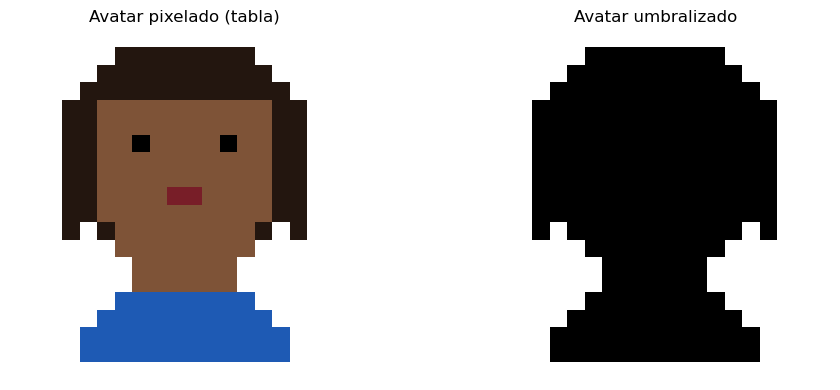

Guardado: e4_avatar_pixel_tabla.png y e4_avatar_umbral_tabla.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 4]

# 0=fondo, 1=piel, 2=cabello, 3=ojos, 4=boca, 5=camisa
avatar_pattern = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,2,2,2,2,2,2,2,2,0,0,0,0,0,0],
    [0,0,0,0,0,2,2,2,2,2,2,2,2,2,2,0,0,0,0,0],
    [0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,2,0,0,0,0],
    [0,0,0,2,2,1,1,1,1,1,1,1,1,1,1,2,2,0,0,0],
    [0,0,0,2,2,1,1,1,1,1,1,1,1,1,1,2,2,0,0,0],
    [0,0,0,2,2,1,1,3,1,1,1,1,3,1,1,2,2,0,0,0],
    [0,0,0,2,2,1,1,1,1,1,1,1,1,1,1,2,2,0,0,0],
    [0,0,0,2,2,1,1,1,1,1,1,1,1,1,1,2,2,0,0,0],
    [0,0,0,2,2,1,1,1,1,4,4,1,1,1,1,2,2,0,0,0],
    [0,0,0,2,2,1,1,1,1,1,1,1,1,1,1,2,2,0,0,0],
    [0,0,0,2,0,2,1,1,1,1,1,1,1,1,2,0,2,0,0,0],
    [0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,5,5,5,5,5,5,5,5,0,0,0,0,0,0],
    [0,0,0,0,0,5,5,5,5,5,5,5,5,5,5,0,0,0,0,0],
    [0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,0,0,0,0],
    [0,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
]

rows, cols = len(avatar_pattern), len(avatar_pattern[0])
avatar = np.zeros((rows, cols, 3), dtype=np.uint8)

fondo = [255, 255, 255]
piel = [126, 83, 55]
cabello = [35, 22, 15]
ojos = [0, 0, 0]
boca = [120, 30, 40]
camisa = [30, 90, 180]

for i in range(rows):
    for j in range(cols):
        v = avatar_pattern[i][j]
        if v == 1:
            avatar[i, j] = piel
        elif v == 2:
            avatar[i, j] = cabello
        elif v == 3:
            avatar[i, j] = ojos
        elif v == 4:
            avatar[i, j] = boca
        elif v == 5:
            avatar[i, j] = camisa
        else:
            avatar[i, j] = fondo

gray = cv2.cvtColor(avatar, cv2.COLOR_RGB2GRAY)
_, umbral = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

plt.subplot(121)
plt.title('Avatar pixelado (tabla)')
plt.imshow(avatar)
plt.axis('off')

plt.subplot(122)
plt.title('Avatar umbralizado')
plt.imshow(umbral, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.imsave('e4_avatar_pixel_tabla.png', avatar)
cv2.imwrite('e4_avatar_umbral_tabla.png', umbral)
print('Guardado ambos')